# Week 4: Stable-Baselines3 — Interactive Tutorial

Learn to use industrial-grade RL algorithms through hands-on practice.

**Learning Objectives:**
- Use SB3's unified API (create, train, evaluate, save/load)
- Compare DQN, PPO, A2C algorithms
- Understand Policy selection (MlpPolicy vs MultiInputPolicy)
- Use vectorized environments for faster training
- Tune hyperparameters

## Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env
print("All imports OK")

All imports OK


## 1. SB3 Unified API

All SB3 algorithms share the same interface:
```python
model = Algorithm("Policy", env)   # create
model.learn(total_timesteps=N)     # train
model.save("name")                 # save
model = Algorithm.load("name")     # load
action, _ = model.predict(obs)     # predict
```

In [2]:
# Train PPO on CartPole-v1
env = gym.make("CartPole-v1")
print(f"Env: CartPole-v1")
print(f"  obs_space: {env.observation_space} (Box, 4 dims)")
print(f"  act_space: {env.action_space} (Discrete, 2 actions)")

model = PPO("MlpPolicy", env, verbose=0, seed=42)
model.learn(total_timesteps=10000)

mean_reward, std = evaluate_policy(model, env, n_eval_episodes=10)
print(f"\nPPO after 10k steps: {mean_reward:.1f} +/- {std:.1f}")
env.close()

Env: CartPole-v1
  obs_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32) (Box, 4 dims)
  act_space: Discrete(2) (Discrete, 2 actions)


C:\Users\40270\OneDrive\Desktop\workspace\aisd\.venv\Lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(



PPO after 10k steps: 433.4 +/- 82.3


### Try It
1. Replace `PPO` with `DQN` or `A2C` and compare results
2. Increase `total_timesteps` to 50000 and see if reward improves
3. Try `deterministic=True` vs `False` in `evaluate_policy`

## 2. Algorithm Comparison

| Algorithm | Type | Action Space | Best For |
|-----------|------|-------------|----------|
| DQN | Off-policy, Value-based | Discrete only | Small discrete |
| PPO | On-policy, Policy Gradient | Both | Default choice |
| A2C | On-policy, Actor-Critic | Both | Simple problems |
| SAC | Off-policy, Max-entropy | Continuous only | Continuous control |

DQN: 11.0 +/- 1.1


PPO: 433.4 +/- 82.3


A2C: 500.0 +/- 0.0


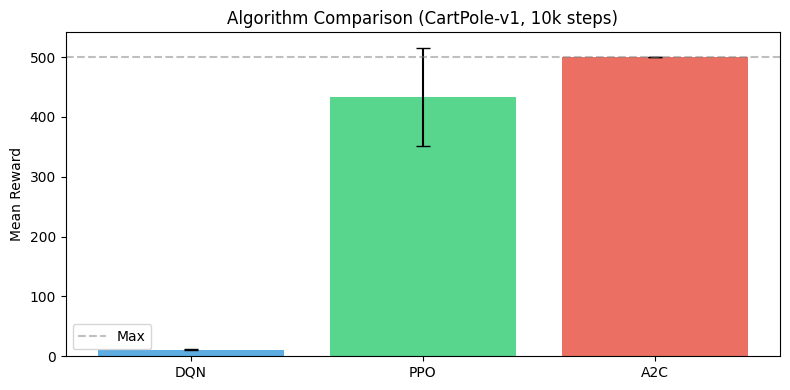

In [3]:
# Compare DQN vs PPO vs A2C on CartPole
algorithms = {"DQN": DQN, "PPO": PPO, "A2C": A2C}
results = {}

for name, Alg in algorithms.items():
    env = gym.make("CartPole-v1")
    model = Alg("MlpPolicy", env, verbose=0, seed=42)
    model.learn(total_timesteps=10000)
    mean_r, std_r = evaluate_policy(model, env, n_eval_episodes=10)
    results[name] = (mean_r, std_r)
    print(f"{name}: {mean_r:.1f} +/- {std_r:.1f}")
    env.close()

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
means = [results[n][0] for n in names]
stds = [results[n][1] for n in names]
ax.bar(names, means, yerr=stds, capsize=5, color=['#3498db','#2ecc71','#e74c3c'], alpha=0.8)
ax.set_ylabel("Mean Reward")
ax.set_title("Algorithm Comparison (CartPole-v1, 10k steps)")
ax.axhline(y=500, color='gray', linestyle='--', alpha=0.5, label='Max')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Policy Selection

Policy must match observation space type:

| Observation | Policy |
|-------------|--------|
| `Discrete(n)` or `Box(d,)` | `MlpPolicy` |
| `Dict({...})` | `MultiInputPolicy` |
| `Box(H,W,C)` images | `CnnPolicy` |

Using the wrong policy will cause an error.

In [4]:
# CartPole uses Box(4,) → MlpPolicy
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print(f"Observation space: {env.observation_space}")
print(f"Sample observation: {obs}")
print(f"→ Use MlpPolicy (flat vector input)")
print()

# What happens with wrong policy?
print("If you used MultiInputPolicy with Box obs, you'd get an error:")
print("  AssertionError: MultiInputPolicy requires Dict observation space")
env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Sample observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
→ Use MlpPolicy (flat vector input)

If you used MultiInputPolicy with Box obs, you'd get an error:
  AssertionError: MultiInputPolicy requires Dict observation space


## 4. Vectorized Environments

Run multiple environments in parallel to collect more data per step:

```python
vec_env = make_vec_env("CartPole-v1", n_envs=4)
model = PPO("MlpPolicy", vec_env)
```

- `DummyVecEnv`: serial (single process) — for simple envs
- `SubprocVecEnv`: parallel (multi-process) — for heavy envs

In [5]:
import time

# Compare training speed with different n_envs
for n_envs in [1, 4, 8]:
    vec_env = make_vec_env("CartPole-v1", n_envs=n_envs, seed=42)
    model = PPO("MlpPolicy", vec_env, verbose=0, seed=42, n_steps=256)
    
    start = time.time()
    model.learn(total_timesteps=10000)
    elapsed = time.time() - start
    
    eval_env = gym.make("CartPole-v1")
    mean_r, _ = evaluate_policy(model, eval_env, n_eval_episodes=5)
    print(f"n_envs={n_envs}: time={elapsed:.2f}s, reward={mean_r:.0f}")
    vec_env.close()
    eval_env.close()

n_envs=1: time=8.06s, reward=500


n_envs=4: time=5.80s, reward=479


n_envs=8: time=4.98s, reward=443


### Try It
1. Try `n_envs=16` — does it get even faster?
2. Note: with more envs, each env runs fewer steps per update

## 5. Hyperparameter Tuning

Key hyperparameters for PPO:

| Parameter | Default | Effect |
|-----------|---------|--------|
| `learning_rate` | 3e-4 | Too high → unstable, too low → slow |
| `gamma` | 0.99 | Near 1 → long-term, near 0 → short-term |
| `n_steps` | 2048 | More → stable but slower |
| `gae_lambda` | 0.95 | 1.0 → high variance, 0.0 → high bias |
| `ent_coef` | 0.0 | Higher → more exploration |

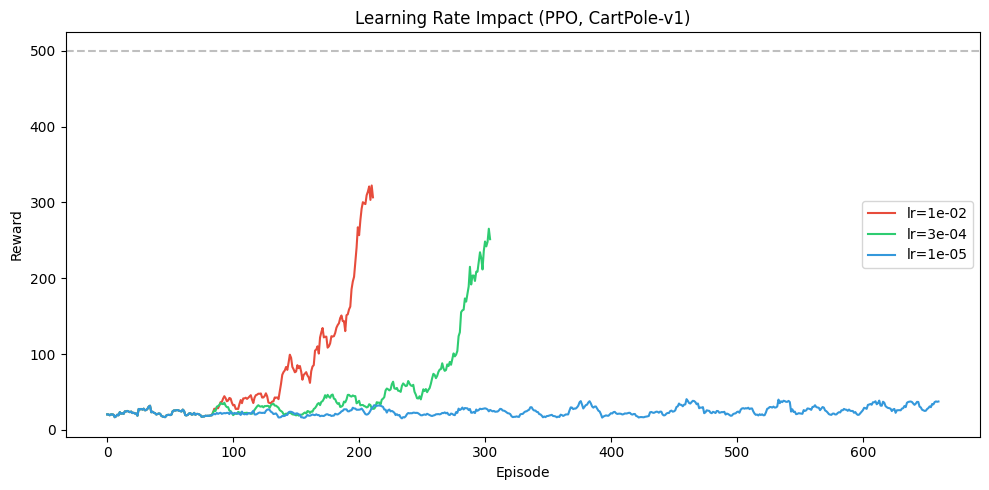

In [6]:
# Compare different learning rates
from stable_baselines3.common.callbacks import BaseCallback

class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._current = 0
    def _on_step(self):
        self._current += self.locals.get("rewards", [0])[0]
        if self.locals.get("dones", [False])[0]:
            self.episode_rewards.append(self._current)
            self._current = 0
        return True

fig, ax = plt.subplots(figsize=(10, 5))
for lr, color in [(1e-2, '#e74c3c'), (3e-4, '#2ecc71'), (1e-5, '#3498db')]:
    env = gym.make("CartPole-v1")
    cb = RewardLogger()
    model = PPO("MlpPolicy", env, learning_rate=lr, verbose=0, seed=42)
    model.learn(total_timesteps=15000, callback=cb)
    if len(cb.episode_rewards) > 10:
        smoothed = np.convolve(cb.episode_rewards, np.ones(10)/10, mode='valid')
        ax.plot(smoothed, label=f"lr={lr:.0e}", color=color, lw=1.5)
    env.close()

ax.set_title("Learning Rate Impact (PPO, CartPole-v1)")
ax.set_xlabel("Episode"); ax.set_ylabel("Reward")
ax.axhline(y=500, color='gray', ls='--', alpha=0.5)
ax.legend(); plt.tight_layout(); plt.show()

## 6. Save, Load, and Deploy

```python
model.save("my_model")           # saves my_model.zip
model = PPO.load("my_model")     # loads from my_model.zip
action, _ = model.predict(obs)   # use in production
```

In [7]:
# Save and reload demo
import tempfile

env = gym.make("CartPole-v1")
model = PPO("MlpPolicy", env, verbose=0, seed=42)
model.learn(total_timesteps=10000)

# Save
path = os.path.join(tempfile.gettempdir(), "ppo_demo")
model.save(path)
print(f"Saved to: {path}.zip")

# Load and evaluate
loaded = PPO.load(path)
mean_r, std_r = evaluate_policy(loaded, env, n_eval_episodes=10)
print(f"Loaded model: {mean_r:.1f} +/- {std_r:.1f}")

# Run one episode
obs, _ = env.reset(seed=0)
total_reward, steps = 0, 0
while True:
    action, _ = loaded.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward; steps += 1
    if terminated or truncated: break
print(f"Demo episode: {steps} steps, reward={total_reward:.0f}")
env.close()

Saved to: C:\Users\40270\AppData\Local\Temp\ppo_demo.zip


Loaded model: 433.4 +/- 82.3
Demo episode: 236 steps, reward=236


## 7. Knowledge Check

**Q1:** Which SB3 algorithm only supports discrete action spaces?
<details><summary>Answer</summary>DQN</details>

**Q2:** What policy should you use with `spaces.Dict` observations?
<details><summary>Answer</summary>MultiInputPolicy</details>

**Q3:** What does `make_vec_env("CartPole-v1", n_envs=8)` do?
<details><summary>Answer</summary>Creates 8 parallel CartPole environments wrapped in a VecEnv</details>

**Q4:** What's the difference between `DummyVecEnv` and `SubprocVecEnv`?
<details><summary>Answer</summary>DummyVecEnv runs envs serially in one process; SubprocVecEnv runs them in parallel across multiple processes</details>

**Q5:** If `learning_rate` is too high, what happens?
<details><summary>Answer</summary>Training becomes unstable — large gradient updates cause the policy to oscillate or diverge</details>

---
## References
- [SB3 Documentation](https://stable-baselines3.readthedocs.io/)
- [SB3 Algorithm Selection Guide](https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html)
- Week 4 Slides: `week4_sb3_slides.md`
- Week 4 Storyline: `week4_sb3_storyline.md`
- Week 4 Tutorial: `week4_sb3_tutorial.md`